In [1]:
!pip install scikit-learn

You should consider upgrading via the 'c:\users\devan\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


In [2]:
import sys
print(sys.executable)

C:\Users\devan\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import sklearn
sklearn.__version__

'1.7.2'

In [4]:
import os
import ember
import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pylab as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [5]:
data_dir = r"C:\Users\devan\OneDrive\Desktop\MLProject\data\archive\ember2018"

In [6]:
os.listdir(data_dir)

['ember_model_2018.txt',
 'metadata.csv',
 'test_features.jsonl',
 'test_metadata.csv',
 'train_features_0.jsonl',
 'train_features_1.jsonl',
 'train_features_2.jsonl',
 'train_features_3.jsonl',
 'train_features_4.jsonl',
 'train_features_5.jsonl',
 'train_metadata.csv',
 'X_test.dat',
 'X_train.dat',
 'y_test.dat',
 'y_train.dat']

In [7]:
emberdf = ember.read_metadata(data_dir)

In [8]:
emberdf

,sha256,appeared,label,avclass,subset
0,0abb4fda7d5b13801d63bee53e5e256be43e141faa077a...,2006-12,0,NaN,train
1,c9cafff8a596ba8a80bafb4ba8ae6f2ef3329d95b85f15...,2007-01,0,NaN,train
2,eac8ddb4970f8af985742973d6f0e06902d42a3684d791...,2007-02,0,NaN,train
3,7f513818bcc276c531af2e641c597744da807e21cc1160...,2007-02,0,NaN,train
4,ca65e1c387a4cc9e7d8a8ce12bf1bcf9f534c9032b9d95...,2007-02,0,NaN,train
...,...,...,...,...,...
999995,e033bc4967ce64bbb5cafdb234372099395185a6e0280c...,2018-12,1,zbot,test
999996,c7d16736fd905f5fbe4530670b1fe787eb12ee86536380...,2018-12,1,flystudio,test
999997,0020077cb673729209d88b603bddf56b925b18e682892a...,2018-12,0,NaN,test
999998,1b7e7c8febabf70d1c17fe3c7abf80f33003581c380f28...,2018-12,0,NaN,test


In [9]:
X_train, y_train, X_test, y_test = ember.read_vectorized_features(data_dir)

In [10]:
X_train

memmap([[1.4676122e-02, 4.2218715e-03, 3.9226813e-03, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.8452372e-01, 3.1307504e-02, 5.6928140e-03, ..., 4.4229600e+05,
         0.0000000e+00, 0.0000000e+00],
        [2.5173673e-01, 1.4204546e-02, 6.8414863e-03, ..., 3.7280000e+04,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [1.4297070e-01, 8.6626979e-03, 4.2015705e-03, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.4780925e-01, 6.4021470e-03, 5.1157344e-03, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.3445158e-01, 6.8144272e-03, 5.5496283e-03, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [11]:
y_train

memmap([0., 0., 0., ..., 0., 1., 1.], dtype=float32)

In [12]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800000, 2381)
Test shape: (200000, 2381)


In [13]:
plotdf = emberdf.copy()
gbdf = plotdf.groupby(["label", "subset"]).count().reset_index()
alt.Chart(gbdf).mark_bar().encode(
    alt.X('subset:O', axis=alt.Axis(title='Subset')),
    alt.Y('sum(sha256):Q', axis=alt.Axis(title='Number of samples')),
    alt.Color('label:N', scale=alt.Scale(range=["#00b300", "#3333ff", "#ff3333"]), legend=alt.Legend(values=["unlabeled", "benign", "malicious"]))
)

alt.Chart(...)

In [14]:
plotdf = emberdf.copy()
plotdf.loc[plotdf["appeared"] < "2018-01", "appeared"] = " <2018"
gbdf = plotdf.groupby(["appeared", "label"]).count().reset_index()
alt.Chart(gbdf).mark_bar().encode(
    alt.X('appeared:O', axis=alt.Axis(title='Month appeared')),
    alt.Y('sum(sha256):Q', axis=alt.Axis(title='Number of samples')),
    alt.Color('label:N', scale=alt.Scale(range=["#00b300", "#3333ff", "#ff3333"]), legend=alt.Legend(values=["unlabeled", "benign", "malicious"]))
)

alt.Chart(...)

**Trying Out Different Models**

LightGBM

In [15]:
import lightgbm as lgb

dtrain = lgb.Dataset(X_train, label=y_train)
dtest = lgb.Dataset(X_test, label=y_test)

In [16]:
params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 2048,
    "max_depth": -1,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.5,
    "bagging_fraction": 0.5,
    "bagging_freq": 1,
    "num_threads": 8
}

In [17]:
# model = lgb.train(
#     params,
#     dtrain,
#     num_boost_round=5000,
#     valid_sets=[dtest],
#     valid_names=['test'],
#     feval=None
# )

In [18]:
lgbm_model = lgb.Booster(model_file=os.path.join(data_dir, "ember_model_2018.txt"))

[LightGBM] [Warning] Ignoring unrecognized parameter 'max_conflict_rate' found in model string.
[LightGBM] [Warning] Ignoring unrecognized parameter 'sparse_threshold' found in model string.
[LightGBM] [Warning] Ignoring unrecognized parameter 'enable_load_from_binary_file' found in model string.
[LightGBM] [Warning] Ignoring unrecognized parameter 'max_position' found in model string.


In [19]:
X_test = np.array(X_test)
y_test_pred = lgbm_model.predict(X_test)

In [20]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    roc_auc_score
)

In [21]:
y_test_pred

array([9.99999999e-01, 8.93433611e-07, 9.99999978e-01, ...,
       4.82357297e-06, 2.98826037e-04, 9.99999779e-01])

In [23]:
y_test_pred = (y_test_pred >= 0.5).astype(int)

In [24]:
y_test_pred

array([1, 0, 1, ..., 0, 0, 1])

In [26]:
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

In [28]:
print("MODEL PERFORMANCE (EMBER Pretrained Model)")
print("=================================================")
print(f"Accuracy:           {acc:.4f}")
print(f"Precision:          {prec:.4f}")
print(f"Recall:             {rec:.4f}")
print(f"F1 Score:           {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

MODEL PERFORMANCE (EMBER Pretrained Model)
Accuracy:           0.9779
Precision:          0.9826
Recall:             0.9731
F1 Score:           0.9778

Confusion Matrix:
[[98272  1728]
 [ 2687 97313]]


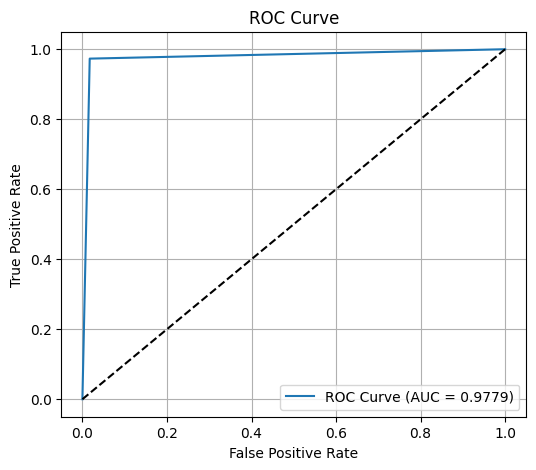

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], 'k--')  # reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


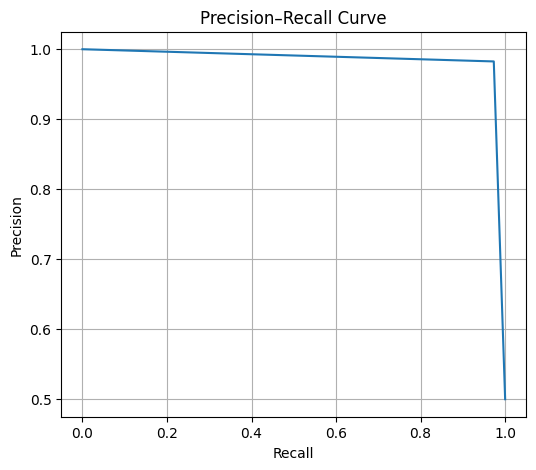

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_test_pred)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()


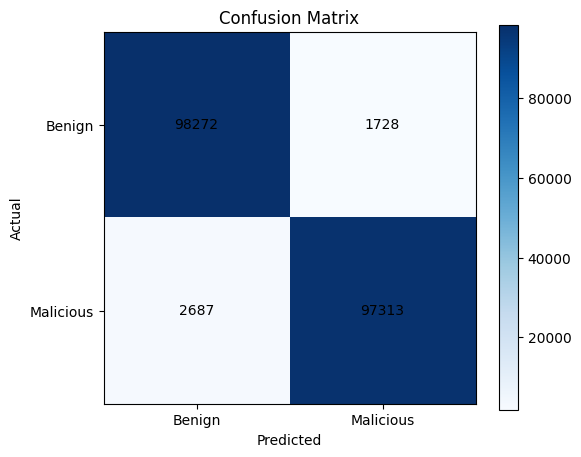

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# Tick labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Benign", "Malicious"])
ax.set_yticklabels(["Benign", "Malicious"])

# Add numbers
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.show()


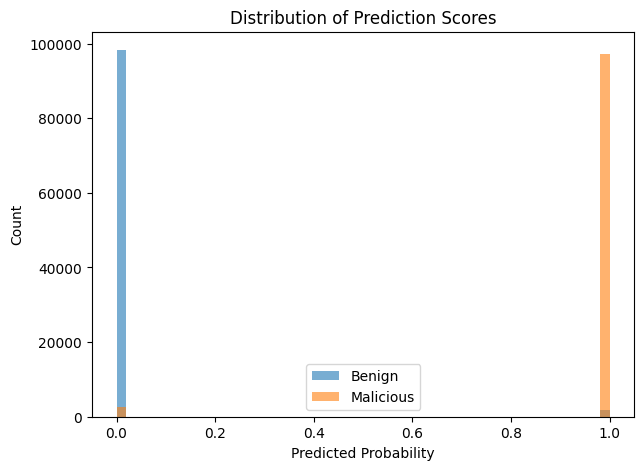

In [32]:
plt.figure(figsize=(7,5))
plt.hist(y_test_pred[y_test == 0], bins=50, alpha=0.6, label="Benign")
plt.hist(y_test_pred[y_test == 1], bins=50, alpha=0.6, label="Malicious")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Prediction Scores")
plt.legend()
plt.show()
